In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [10]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

print("NAV Shape:", nav.shape)
print("Transactions Shape:", transactions.shape)
print("Performance Shape:", performance.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Performance Shape: (40, 19)


In [4]:
datasets = {
    "NAV": nav,
    "Transactions": transactions,
    "Performance": performance
}

for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:", df.duplicated().sum())


NAV
Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']

Missing Values:
amfi_code    0
date         0
nav          0
dtype: int64

Duplicate Rows: 0

Transactions
Shape: (32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Missing Values:
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

Duplicate Rows: 0

Performance
Shape: (40, 19)

Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_d

In [5]:
nav.describe(include="all")

,amfi_code,date,nav
count,46000.000000,46000,46000.000000
unique,NaN,1150,NaN
top,NaN,2022-01-03,NaN
freq,NaN,40,NaN
mean,120247.000000,NaN,269.570265
std,14352.317221,NaN,577.187060
min,100016.000000,NaN,26.136600
25%,118632.750000,NaN,69.170425
50%,119551.500000,NaN,122.732150
75%,120842.250000,NaN,260.338675


In [6]:
transactions.describe(include="all")

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
count,32778,32778,32778.000000,32778,32778.000000,32778,32778,32778,32778,32778,32778.000000,32778,32778
unique,5000,516,NaN,3,NaN,12,24,2,5,2,NaN,4,2
top,INV001497,2025-04-28,NaN,Sip,NaN,Punjab,Kolkata,T30,26-35,Male,NaN,Net Banking,Verified
freq,12,88,NaN,19716,NaN,2965,2748,21719,13463,21809,NaN,8250,30146
mean,NaN,NaN,120264.617518,NaN,107437.318628,NaN,NaN,NaN,NaN,NaN,26.181219,NaN,NaN
std,NaN,NaN,14370.205345,NaN,150415.905084,NaN,NaN,NaN,NaN,NaN,20.805425,NaN,NaN
min,NaN,NaN,100016.000000,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN
25%,NaN,NaN,118632.000000,NaN,3153.000000,NaN,NaN,NaN,NaN,NaN,10.600000,NaN,NaN
50%,NaN,NaN,119551.000000,NaN,17782.500000,NaN,NaN,NaN,NaN,NaN,19.700000,NaN,NaN
75%,NaN,NaN,120843.000000,NaN,189324.250000,NaN,NaN,NaN,NaN,NaN,37.400000,NaN,NaN


In [7]:
performance.describe(include="all")

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
count,40.000000,40,40,40,40,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000,40
unique,NaN,40,10,12,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Moderate
freq,NaN,1,5,14,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16
mean,120247.000000,NaN,NaN,NaN,NaN,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000,NaN
std,14534.998667,NaN,NaN,NaN,NaN,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484,NaN
min,100016.000000,NaN,NaN,NaN,NaN,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000,NaN
25%,118632.750000,NaN,NaN,NaN,NaN,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000,NaN
50%,119551.500000,NaN,NaN,NaN,NaN,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000,NaN
75%,120842.250000,NaN,NaN,NaN,NaN,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000,NaN


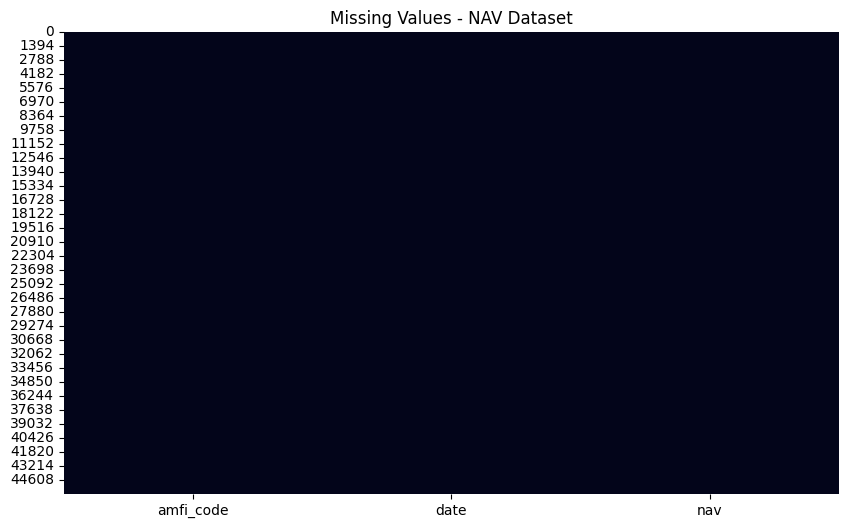

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(nav.isnull(), cbar=False)
plt.title("Missing Values - NAV Dataset")
plt.show()

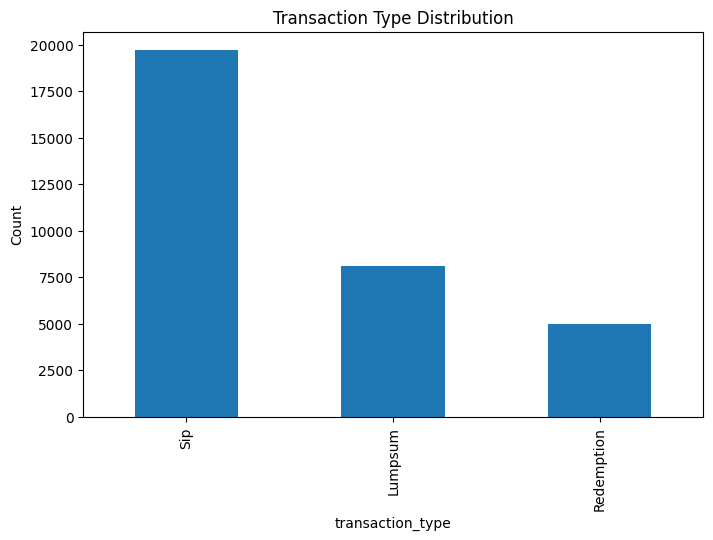

In [9]:
transactions["transaction_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Transaction Type Distribution")
plt.ylabel("Count")
plt.show()

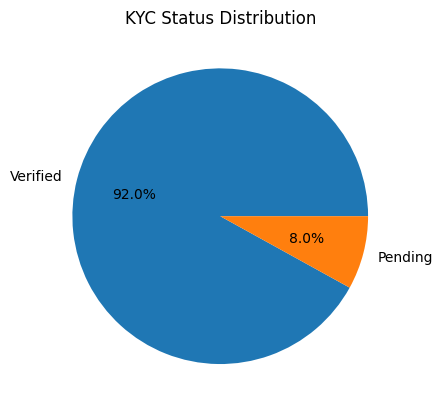

In [10]:
transactions["kyc_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("KYC Status Distribution")
plt.ylabel("")
plt.show()

In [11]:
import pandas as pd

files = [
    "../data/processed/nav_history_clean.csv",
    "../data/processed/investor_transactions_clean.csv",
    "../data/processed/scheme_performance_clean.csv"
]

for f in files:
    df = pd.read_csv(f)
    print("\n", f)
    print(df.columns.tolist())


 ../data/processed/nav_history_clean.csv
['amfi_code', 'date', 'nav']

 ../data/processed/investor_transactions_clean.csv
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

 ../data/processed/scheme_performance_clean.csv
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [12]:
transactions["transaction_type"].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [14]:
nav["date"] = pd.to_datetime(nav["date"])

In [15]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [16]:
nav["amfi_code"].nunique()

40

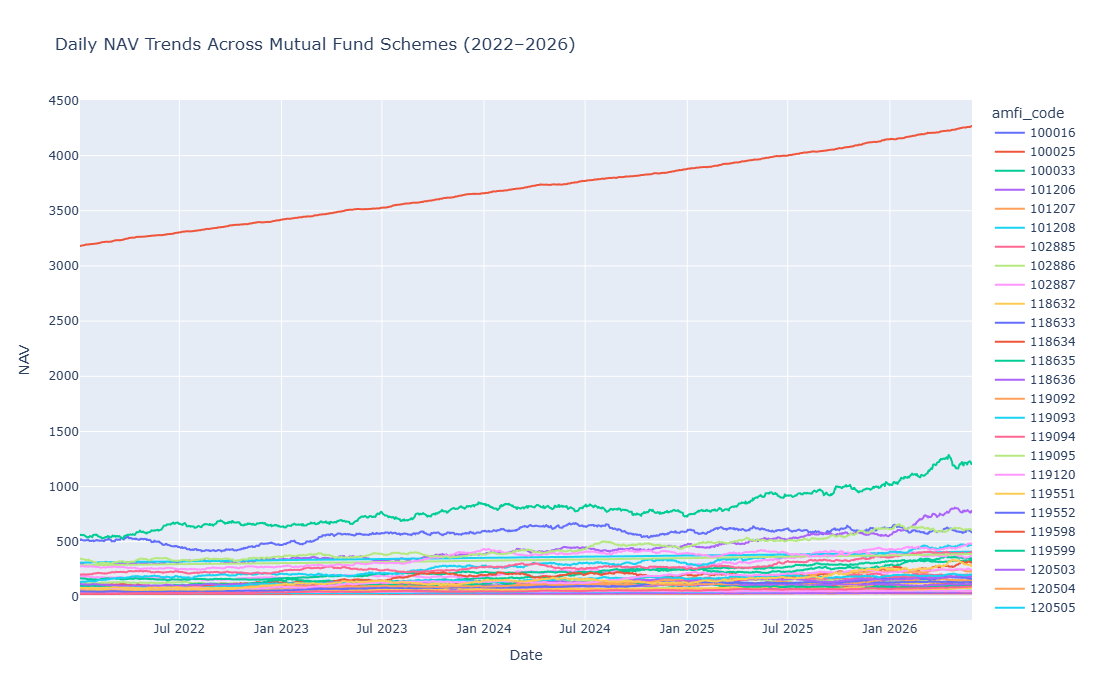

In [18]:
import plotly.express as px

nav["amfi_code"] = nav["amfi_code"].astype(str)

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends Across Mutual Fund Schemes (2022–2026)"
)

fig.update_layout(
    height=700,
    xaxis_title="Date",
    yaxis_title="NAV"
)

fig.show()

In [15]:
import os

os.path.exists("../reports/nav_trend.png")

True

In [16]:
import os

os.listdir("../reports")

['age_group_distribution.png',
 'chart.png',
 'chart_name.png',
 'data_quality_summary.txt.txt',
 'nav_trend.png']

In [17]:
os.path.exists("../reports")
os.listdir("../reports")

['age_group_distribution.png',
 'chart.png',
 'chart_name.png',
 'data_quality_summary.txt.txt',
 'nav_trend.png']

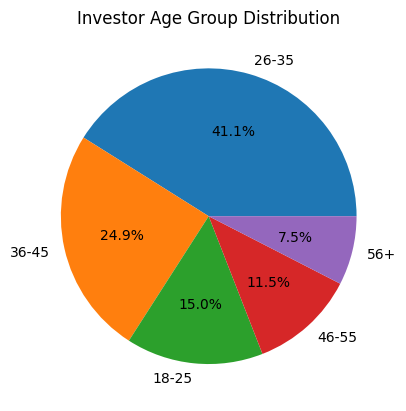

In [18]:
import matplotlib.pyplot as plt

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

In [19]:
plt.savefig("../reports/age_group_distribution.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [20]:
plt.savefig("../reports/chart.png", bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

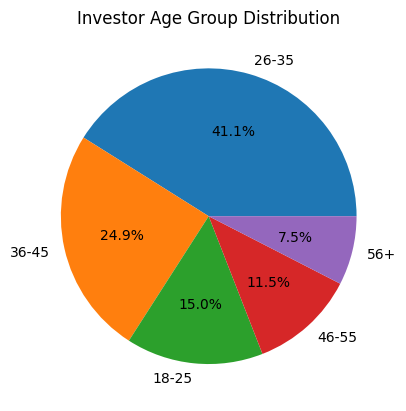

In [21]:
import matplotlib.pyplot as plt

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

In [22]:
plt.savefig("../reports/age_group_distribution.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [23]:
plt.savefig("../reports/chart.png", bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [24]:
plt.show()

plt.savefig("../reports/age_group_distribution.png")

<Figure size 640x480 with 0 Axes>

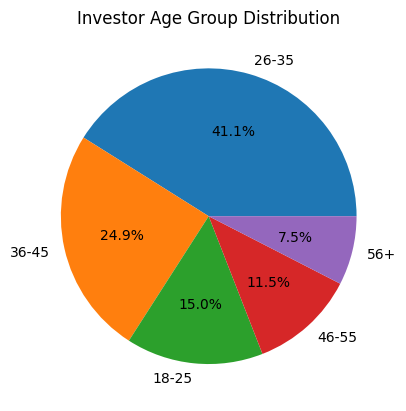

In [25]:
import matplotlib.pyplot as plt

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.savefig(
    "../reports/age_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [26]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [28]:
%whos

Variable       Type         Data/Info
-------------------------------------
df             DataFrame    Shape: (40, 19)
f              str          ../data/processed/scheme_performance_clean.csv
files          list         n=3
nav            DataFrame    Shape: (46000, 3)
np             module       <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
os             module       <module 'os' (frozen)>
pd             module       <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
performance    DataFrame    Shape: (40, 19)
plt            module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
sns            module       <module 'seaborn' from 'C<...>s\\seaborn\\__init__.py'>
transactions   DataFrame    Shape: (32778, 13)


In [29]:
import os
os.listdir("../reports")

['age_group_distribution.png',
 'chart.png',
 'chart_name.png',
 'data_quality_summary.txt.txt',
 'nav_trend.png']

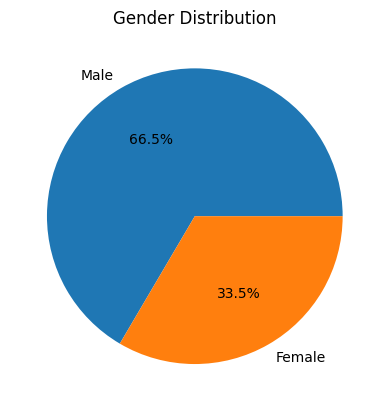

In [30]:
import matplotlib.pyplot as plt

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.savefig(
    "../reports/gender_distribution.png",
    bbox_inches="tight"
)

plt.show()

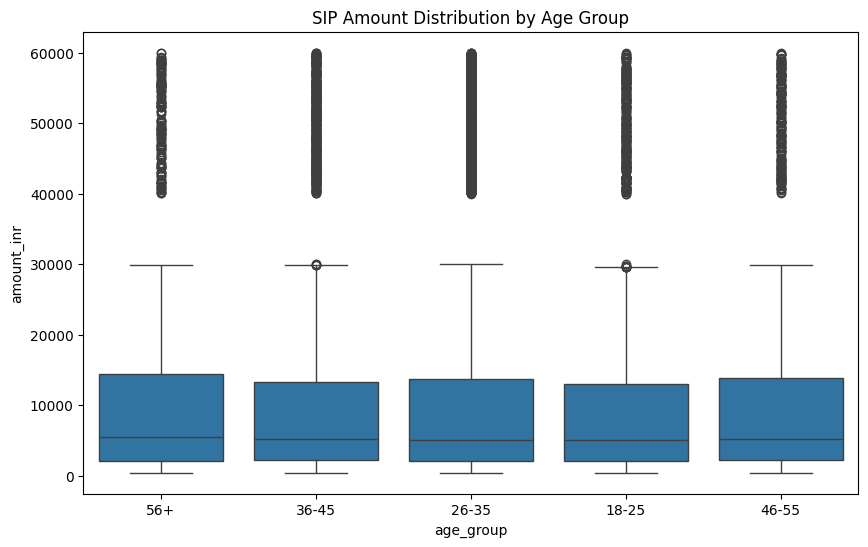

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sip = transactions[
    transactions["transaction_type"] == "Sip"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.savefig(
    "../reports/sip_amount_by_age_group.png",
    bbox_inches="tight"
)

plt.show()

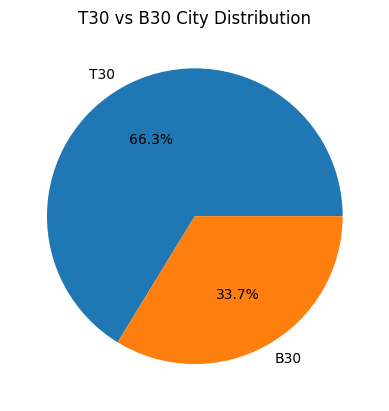

In [32]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 City Distribution")
plt.ylabel("")

plt.savefig(
    "../reports/t30_b30_distribution.png",
    bbox_inches="tight"
)

plt.show()